In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('petrol_prices_pakistan_2010_2025.csv')
df.columns = ['Date', 'Price']
print(df.head())
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())


      Date  Price
0  2010-01  66.36
1  2010-02  66.36
2  2010-03  69.03
3  2010-04  71.21
4  2010-05  72.96
Date         str
Price    float64
dtype: object
Date     0
Price    0
dtype: int64
            Price
count  185.000000
mean   128.855459
std     69.915823
min     66.360000
25%     85.000000
50%    100.100000
75%    120.500000
max    292.000000


In [4]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m')
df = df.sort_values('Date').reset_index(drop=True)
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

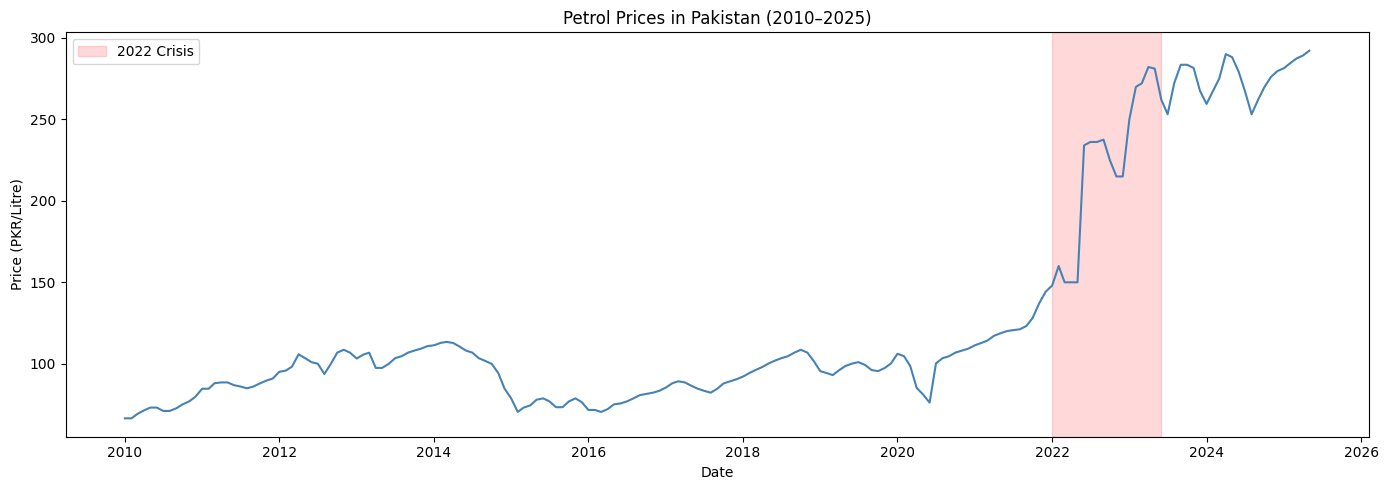

In [6]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Price'], color='steelblue', linewidth=1.5)
plt.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2023-06-01'),
            alpha=0.15, color='red', label='2022 Crisis')
plt.title('Petrol Prices in Pakistan (2010–2025)')
plt.xlabel('Date')
plt.ylabel('Price (PKR/Litre)')
plt.legend()
plt.tight_layout()
plt.savefig('price_trend.png', dpi=150)
plt.show()

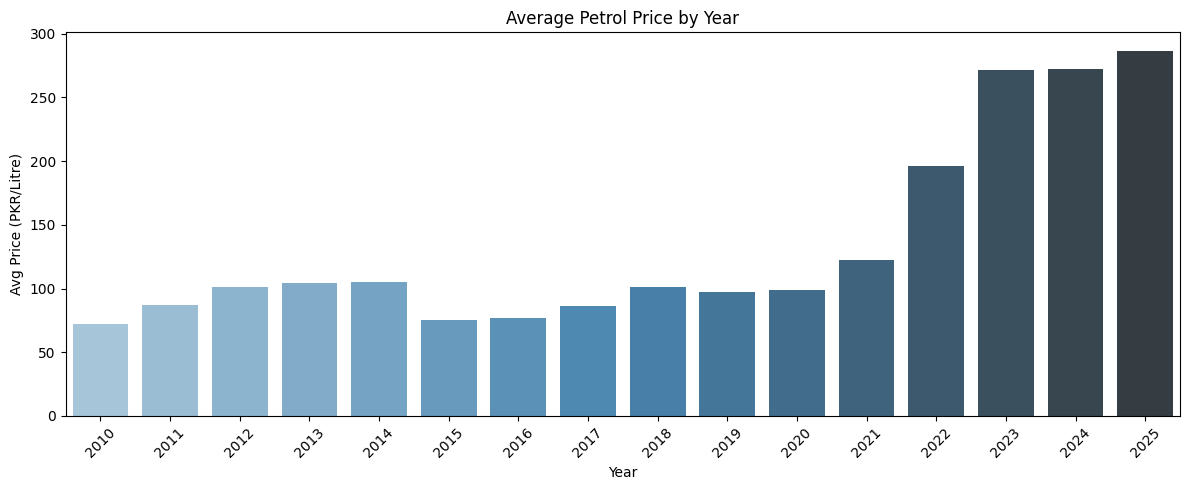

In [8]:
yearly = df.groupby('Year')['Price'].mean().reset_index()
plt.figure(figsize=(12, 5))
sns.barplot(x='Year', y='Price', data=yearly, palette='Blues_d')
plt.title('Average Petrol Price by Year')
plt.xlabel('Year')
plt.ylabel('Avg Price (PKR/Litre)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('avg_price_by_year.png', dpi=150)
plt.show()

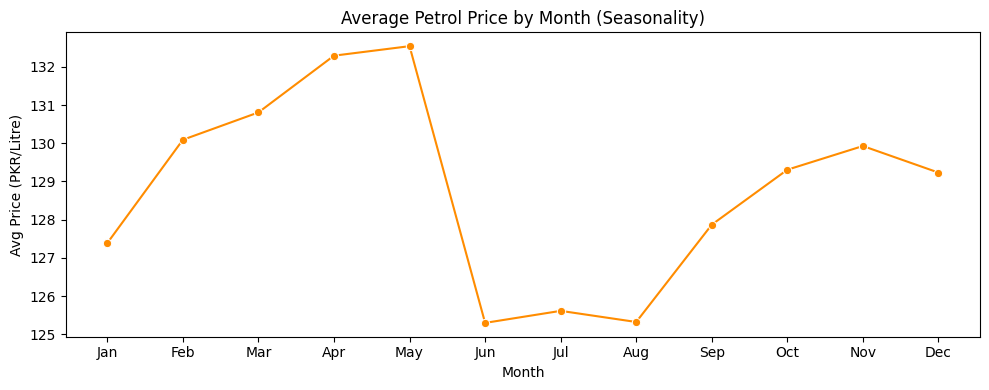

In [9]:
monthly = df.groupby('Month')['Price'].mean().reset_index()
plt.figure(figsize=(10, 4))
sns.lineplot(x='Month', y='Price', data=monthly, marker='o', color='darkorange')
plt.title('Average Petrol Price by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Avg Price (PKR/Litre)')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.savefig('seasonality.png', dpi=150)
plt.show()

In [11]:
df['Lag_1']     = df['Price'].shift(1)
df['Lag_2']     = df['Price'].shift(2)
df['Lag_3']     = df['Price'].shift(3)
df['Rolling_3'] = df['Price'].shift(1).rolling(3).mean()
df = df.dropna().reset_index(drop=True)

In [12]:
features = ['Year', 'Month', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_3']
X = df[features]
y = df['Price']

In [13]:
split = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


In [15]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=0.1),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42)
}


In [16]:
print("\n── Model Results ──")
results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    r2    = r2_score(y_test, preds)
    results[name] = {'model': model, 'preds': preds, 'rmse': rmse, 'r2': r2}
    print(f"{name:20s} | RMSE: {rmse:7.2f} | R²: {r2:.4f}")



── Model Results ──
Linear Regression    | RMSE:   18.19 | R²: 0.2779
Ridge                | RMSE:   18.35 | R²: 0.2655
Lasso                | RMSE:   18.10 | R²: 0.2852
Random Forest        | RMSE:  117.82 | R²: -29.2786


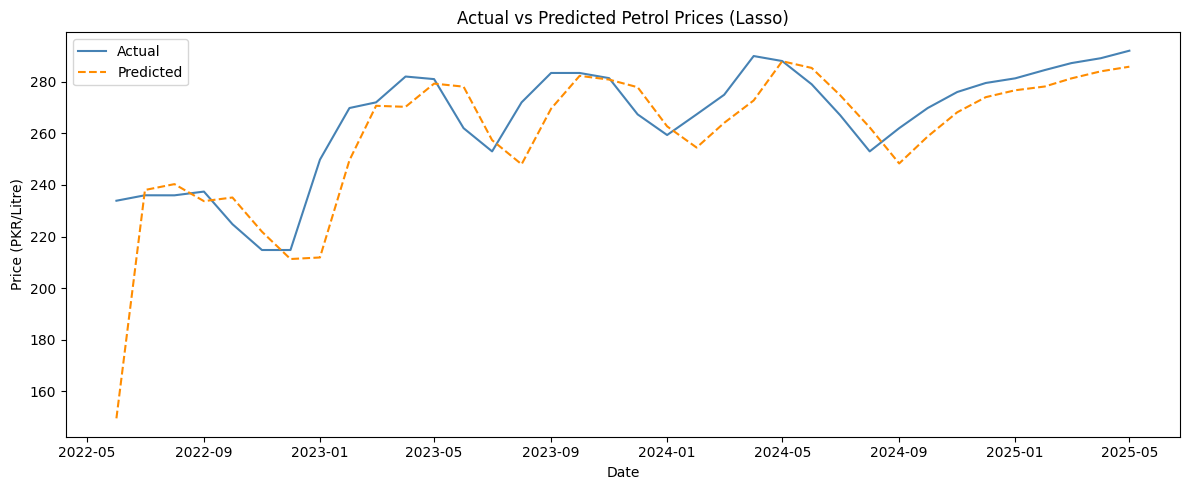

In [18]:
best_name  = max(results, key=lambda x: results[x]['r2'])
best_preds = results[best_name]['preds']

plt.figure(figsize=(12, 5))
plt.plot(df['Date'].iloc[split:].values, y_test.values,
         label='Actual', color='steelblue', linewidth=1.5)
plt.plot(df['Date'].iloc[split:].values, best_preds,
         label='Predicted', color='darkorange', linewidth=1.5, linestyle='--')
plt.title(f'Actual vs Predicted Petrol Prices ({best_name})')
plt.xlabel('Date')
plt.ylabel('Price (PKR/Litre)')
plt.legend()
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()
